In [138]:
import numpy as np
import matplotlib.pyplot as plt
import hamhelper.plotting as hp

## Ring Project

In [139]:
# Constants
c = 3e8  # Speed of light in m/s

# Material
def group_index(n_eff, dn_dlambda, lambda_0):
    """
    Calculate the group index of a waveguide.

    Parameters:
    n_eff (float): The effective refractive index of the waveguide.
    dn_dlambda (float): The derivative of the effective index with respect to wavelength.
    lambda_0 (float): The central wavelength in meters.

    Returns:
    float: The group index.
    """
    return n_eff - lambda_0 * dn_dlambda

# RIng
def fsr_freq(L, n_g):
    """
    Calculate the Free Spectral Range (FSR) in Hz for a ring resonator.

    Parameters:
    L (float): The round-trip length of the ring in meters.
    n_g (float): The group index of the waveguide.

    Returns:
    float: The FSR in Hz.
    """
    return c / (n_g * L)

def fsr_wl(L, n_g, lambda_0):
    """
    Calculate the Free Spectral Range (FSR) in wavelength for a ring resonator.

    Parameters:
    L (float): The round-trip length of the ring in meters.
    n_g (float): The group index of the waveguide.
    lambda_0 (float): The central wavelength in meters.

    Returns:
    float: The FSR in meters.
    """
    f = fsr_freq(L, n_g)
    return lambda_0**2 / (c / f)

def loaded_q(q_i, q_c):
    """
    Calculate the loaded quality factor (Q) of a ring resonator.

    Parameters:
    q_i (float): The intrinsic quality factor.
    q_c (float): The coupling quality factor.

    Returns:
    float: The loaded quality factor.
    """
    return 1 / (1/q_i + 1/q_c)

def intrinsic_q(a, t):
    """
    Calculate the intrinsic quality factor (Q) of a ring resonator.

    Parameters:
    a (float): The amplitude transmission coefficient.
    t (float): The round-trip transmission coefficient.

    Returns:
    float: The intrinsic quality factor.
    """
    return np.pi * np.sqrt(t) / (1 - a * t)

def coupling_q(kappa, a, t):
    """
    Calculate the coupling quality factor (Q) of a ring resonator.

    Parameters:
    kappa (float): The coupling coefficient.
    a (float): The amplitude transmission coefficient.
    t (float): The round-trip transmission coefficient.

    Returns:
    float: The coupling quality factor.
    """
    return np.pi * np.sqrt(t) / (kappa**2)

def input_coupling(kappa, a, t):
    """
    Calculate the input coupling coefficient for a ring resonator.

    Parameters:
    kappa (float): The coupling coefficient.
    a (float): The amplitude transmission coefficient.
    t (float): The round-trip transmission coefficient.

    Returns:
    float: The input coupling coefficient.
    """
    return kappa**2 / (1 - a * t)**2

@np.vectorize
def ring_trip_a(atten_dB_m, L):
    """
    Calculate the amplitude transmission coefficient (a) for a ring resonator.

    Parameters:
    atten (float): The attenuation in dB/m.
    L (float): The round-trip length of the ring in meters.

    Returns:
    float: The amplitude transmission coefficient.
    """
    alpha = atten_dB_m * (np.log(10) / 10)
    return np.exp(-alpha * L / 2)

@np.vectorize
def ring_trip_phase(n_eff, L, lambda_0):
    """
    Calculate the round-trip phase shift for a ring resonator.

    Parameters:
    n_eff (float): The effective refractive index of the waveguide.
    L (float): The round-trip length of the ring in meters.
    lambda_0 (float): The central wavelength in meters.

    Returns:
    float: The round-trip phase shift in radians.
    """
    return 2 * np.pi * n_eff * L / lambda_0

# Singlebus
def transmission_allpass(t, a, theta):
    """
    Calculates the exact Thru-port power transmission of a single-bus ring.
    Handles both scalar values and NumPy arrays instantly.
    """
    numerator = t**2 - 2 * a * t * np.cos(theta) + a**2
    denominator = 1 - 2 * a * t * np.cos(theta) + (a * t)**2
    return numerator / denominator

# Singlebus q's
def single_bus_q_factors(n_g, L, lambda_0, a, t):
    """
    Calculates Q-factors for a single-bus (all-pass) ring resonator.
    """
    omega_0 = 2 * np.pi * (c / lambda_0)
    round_trip_time = (n_g * L) / c
    
    # Internal roundtrip power loss rate
    loss_rate_intrinsic = (1 - a**2) / round_trip_time
    # Coupling extraction rate out back to the bus
    loss_rate_coupling = (1 - t**2) / round_trip_time
    
    q_i = omega_0 / loss_rate_intrinsic
    q_c = omega_0 / loss_rate_coupling
    q_l = 1 / (1 / q_i + 1 / q_c)
    
    return q_i, q_c, q_l

def field_enhancement_allpass(t, a, theta):
    """
    Calculate the electric field amplitude enhancement factor (FE) inside the ring.
    
    Parameters:
    t (float): Self-coupling coefficient.
    a (float): Round-trip amplitude transmission factor.
    theta (array): Round-trip phase shift array in radians.
    
    Returns:
    array: Field enhancement factor spectrum.
    """
    kappa = np.sqrt(1 - t**2)
    # Complex field representation to capture phase and magnitude
    numerator = kappa
    denominator = 1 - a * t * np.exp(-1j * theta)
    return np.abs(numerator / denominator)


# Doublebus
@np.vectorize
def transmission_thru(t1, t2, a, theta):
    numerator   = t1**2 - 2*a*t1*t2*np.cos(theta) + (a*t2)**2
    denominator = 1     - 2*a*t1*t2*np.cos(theta) + (a*t1*t2)**2
    return numerator / denominator
# Doublebus
@np.vectorize
def transmission_drop(t1, t2, a, theta):
    numerator   = (1 - t2**2) * (1 - t2**2) * a
    denominator = 1 - 2*a*t1*t2*np.cos(theta) + (a*t1*t2)**2
    return numerator / denominator

# Dispersion
def d1(n_g, L):
    """
    Calculate the first-order dispersion parameter (D1) for a ring resonator.

    Parameters:
    n_g (float): The group index of the waveguide.
    L (float): The round-trip length of the ring in meters.

    Returns:
    float: The first-order dispersion parameter in Hz.
    """
    return 2*np.pi*fsr_freq(L, n_g)

def d2(n_g, L, beta_2, lambda_0):
    """
    Calculate the second-order dispersion parameter (D2) for a ring resonator.

    Parameters:
    n_g (float): The group index of the waveguide.
    L (float): The round-trip length of the ring in meters.
    dn_dlambda (float): The derivative of the effective index with respect to wavelength.
    lambda_0 (float): The central wavelength in meters.

    Returns:
    float: The second-order dispersion parameter in Hz^2.
    """
    return -c*d1(n_g, L)**2 /n_g * beta_2

def dispersion_walk_off(d2, m):
    return np.abs(d2) * m**2

def resonator_linewidth(f_res, q_loaded):
    """
    Calculate the linewidth of a ring resonator.

    Parameters:
    f_res (float): The resonance frequency in Hz.
    q_loaded (float): The loaded quality factor.

    Returns:
    float: The linewidth in Hz.
    """
    return f_res / q_loaded

# Nonlinear
def nonlinear_parameter(n2, A_eff, lambda_0):
    """
    Calculate the nonlinear parameter (gamma) for a waveguide.

    Parameters:
    n2 (float): The nonlinear refractive index in m^2/W.
    A_eff (float): The effective mode area in m^2.
    lambda_0 (float): The central wavelength in meters.

    Returns:
    float: The nonlinear parameter in 1/(W*m).
    """
    return 2 * np.pi * n2 / (lambda_0 * A_eff)

def sfwm_idler_freq(f_pump, f_signal):
    """
    Calculate the idler frequency for a four-wave mixing process.

    Parameters:
    f_pump (float): The pump frequency in Hz.
    f_signal (float): The signal frequency in Hz.

    Returns:
    float: The idler frequency in Hz.
    """
    return 2 * f_pump - f_signal

Estimated round-trip length for FSR of 0.5 nm at 1310 nm1806.4211 um
	L = 1806.4211 um
	R = 287.5008 um
	Contained mode indices: 2620.00 $\lambda$
	Rounded L = 1806.4211 um

To not exceed a radius of 500 um, the minimum target FSR is 0.26 nm.


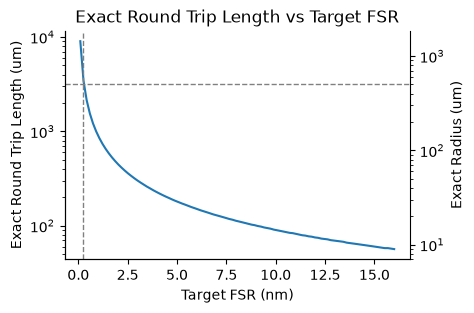

In [140]:
# Estimates for Si3N4
n_eff = 1.9
dn_dlambda = -0.02  # derivative of effective index with respect to wavelength
n_g = group_index(n_eff, dn_dlambda, wl_pump * 1e-9)

# Estimate geometry for a ring resonating at 1310 and +/- 5nm
fsr_targ = 0.5     # nm
wl_center = 1310  # nm

L = (wl_center**2) / (fsr_targ * n_g)  # Round-trip length in nm
L /= 1000  # Convert to um
R = L / (2 * np.pi)  # Radius in um


print(f"Estimated round-trip length for FSR of {fsr_targ} nm at {wl_center} nm{L:.4f} um")
print(f"\tL = {L:.4f} um\n\tR = {R:.4f} um")

# Nearest index
m = n_eff* L / (wl_center * 1e-3)  # Convert wl_center to um
print(f"\tContained mode indices: {m:.2f} "+r"$\lambda$")

# Tune exact round trip length to be an integer number of wavelengths
L_exact = m * wl_center * 1e-3 / n_eff  # Convert wl_center to um
R_exact = L_exact / (2 * np.pi)
print(f"\tRounded L = {L_exact:.4f} um")

# Save as baseline
r0 = R_exact

# Plot of exact round trip length vs FSR for FSR from 0.1 to 16nm
x_space = np.linspace(0.1, 16, 100)  # FSR
# For each, count modes and calculate exact round trip length to mode match
y_space = []
for fsr in x_space:
    L_temp = (wl_center**2) / (fsr * n_g)  # Round-trip length in nm
    L_temp /= 1000  # Convert to um
    m_temp = n_eff* L_temp / (wl_center * 1e-3)  # Convert wl_center to um
    m_temp = np.round(m_temp)  # Nearest integer mode index
    L_exact_temp = m_temp * wl_center * 1e-3 / n_eff  # Exact round trip length in um
    y_space.append(L_exact_temp)

fig, ax = plt.subplots(figsize=np.array([3.3, 2.2])*1.35)
ax.plot(x_space, y_space)

ax.set(yscale='log',
       xlabel='Target FSR (nm)',
       ylabel='Exact Round Trip Length (um)',
       title='Exact Round Trip Length vs Target FSR')

# Add a second yscale scaled appropriately for radius in um
ax2 = ax.twinx()
ax2.set(yscale='log',
        ylabel='Exact Radius (um)')
# Adjust the second y-axis to match the radius
ax2.set_ylim(np.array(ax.get_ylim()) / (2 * np.pi))

max_radius = 500  # um
max_length = max_radius * 2 * np.pi
# Match this max length to the closest FSR in the x_space
min_target_fsr = x_space[np.argmin(np.abs(np.array(y_space) - max_length))]

print(f"\nTo not exceed a radius of {max_radius} um, the minimum target FSR is {min_target_fsr:.2f} nm.")

ax.axhline(max_length, color='gray', linestyle='--', linewidth=1)
ax.axvline(min_target_fsr, color='gray', linestyle='--', linewidth=1)

hp.despine(ax)
hp.despine(ax2, right=True)
plt.show()

--- Single Bus Verification ---
Mode (m): 6 | Radius: 0.658 um
Loaded Q: 1.403e+04 | Intrinsic Q: 7.317e+06
Coupling Target t: 0.9800 (Overcoupled because t < a=1.0000)


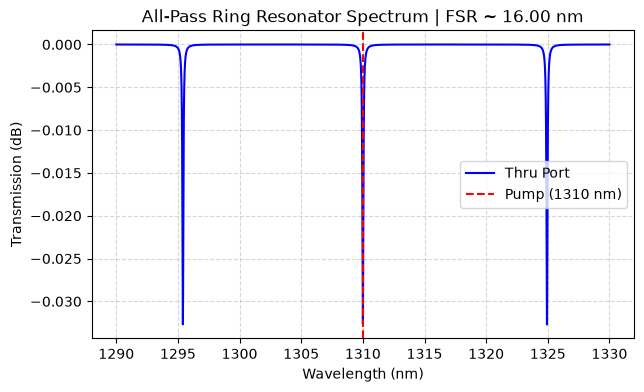

In [141]:
# Given a ring geometry plot FSR and coupling
r = r0  * 1e-6          # ring radius converted from um to meters
g = 0.2 * 1e-6         # coupling gap in meters
wl_pump = 1310 * 1e-9  # pump wavelength in meters

wl_min = wl_pump - 30 * 1e-9
wl_max = wl_pump + 30 * 1e-9
res = 1000
wl_arr = np.linspace(wl_min, wl_max, res)

# --- BUG FIX 1: Account for n_eff dispersion ---
n_eff_pump = 1.9
dn_dlambda = -0.02 * 1e9  # Convert -0.02/nm to -2e7 per meter
# Linear Taylor expansion of n_eff over the wavelength array
n_eff_arr = n_eff_pump + dn_dlambda * (wl_arr - wl_pump)

# --- BUG FIX 2: Correctly scale loss by micro-ring length ---
loss_dB_m = 0.8  # Propagation loss in dB/m
L = 2 * np.pi * r
loss_dB_roundtrip = loss_dB_m * L
a = 10**(-loss_dB_roundtrip / 20)  # Amplitude transmission factor (close to 0.9999)

# Fixed coupling coefficients (substitute your gap-dependent function later)
t1 = 0.98  
t2 = 0.98  

# Phase calculations using the dispersed n_eff array
theta = ring_trip_phase(n_eff_arr, L, wl_arr)
transmission_through = transmission_thru(t1, t2, a, theta)
transmission_dropped = transmission_drop(t1, t2, a, theta)

# 1. Geometry Setup from your Si3N4 baseline
wl_pump    = 1310 * 1e-9  # 1310 nm
n_eff_pump =  1.9
dn_dlambda = -0.02 * 1e9  # Convert -0.02/nm to -2e7 / meter
atten_dB_cm = 0.8

fsr_targ = 16 * 1e-9  # 16 nm target
wl_sweep = 20 * 1e-9  # +/- 30 nm sweep around pump

n_g = group_index(n_eff_pump, dn_dlambda, wl_pump)

# Find the exact resonant length matching
L_estimate = (wl_pump**2) / (fsr_targ * n_g)
# Round to nearest integer mode
m = np.round((n_eff_pump * L_estimate) / wl_pump)
L_exact = (m * wl_pump) / n_eff_pump
r_exact = L_exact / (2 * np.pi)

# 2. Loss & Coupling
atten_dB_m = atten_dB_cm * 100  # Convert from dB/cm to dB/m
a = ring_trip_a(atten_dB_m, L_exact)
t = 0.98 * a  # ??? Over coupling condition?

# 3. Frequency/Wavelength Grid Setup
wl_min = wl_pump - wl_sweep
wl_max = wl_pump + wl_sweep
wl_arr = np.linspace(wl_min, wl_max, 10000)

# Apply index dispersion across the array
n_eff_arr = n_eff_pump + dn_dlambda * (wl_arr - wl_pump)
theta = ring_trip_phase(n_eff_arr, L_exact, wl_arr)

# 4. Transmission
transmission = transmission_allpass(t, a, theta)
transmission_dB = 10 * np.log10(transmission)

# 5. Output calculations
q_i, q_c, q_l = single_bus_q_factors(n_g, L_exact, wl_pump, a, t)
print(f"--- Single Bus Verification ---")
print(f"Mode (m): {int(m)} | Radius: {r_exact*1e6:.3f} um")
print(f"Loaded Q: {q_l:.3e} | Intrinsic Q: {q_i:.3e}")
print(f"Coupling Target t: {t:.4f} (Overcoupled because t < a={a:.4f})")

# 6. Render
plt.figure(figsize=(7, 4))
plt.plot(wl_arr * 1e9, transmission_dB, color='blue', label='Thru Port')
plt.axvline(x=wl_pump * 1e9, color='red', linestyle='--', label='Pump (1310 nm)')
plt.title(f'All-Pass Ring Resonator Spectrum | FSR ~ {fsr_targ*1e9:.2f} nm')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Transmission (dB)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

--- Intracavity Field Dynamics ---
Peak Field Amplitude Enhancement: 9.92x
Peak Intracavity Power Buildup (FE^2): 98.45x
SFWM Classical Scaling Factor (FE^4): 9691.70x
SFWM Quantum Pair Generation Boost (FE^8): 93,929,007x


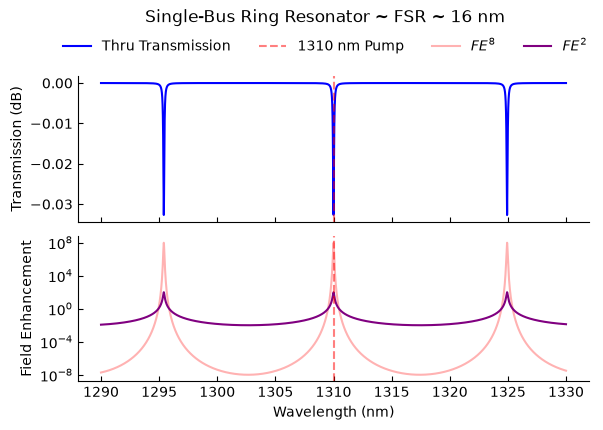

In [142]:
kappa = np.sqrt(1 - t**2)
fe_amplitude = np.abs(kappa / (1 - a * t * np.exp(-1j * theta)))
power_buildup = fe_amplitude**2

# 2. Extract metrics at the pump center
fe_peak = kappa / (1 - a * t)
power_peak = fe_peak**2

print(f"--- Intracavity Field Dynamics ---")
print(f"Peak Field Amplitude Enhancement: {fe_peak:.2f}x")
print(f"Peak Intracavity Power Buildup (FE^2): {power_peak:.2f}x")
print(f"SFWM Classical Scaling Factor (FE^4): {power_peak**2:.2f}x")
print(f"SFWM Quantum Pair Generation Boost (FE^8): {fe_peak**8:,.0f}x")

# 3. Enhanced Double Plot Configuration
# Compressed height to match your target aspect ratio
fig, (ax_thru, ax_fe) = plt.subplots(2, 1, figsize=np.array([3.3*2, 2.2*1.8]), sharex=True)

# Remove the vertical gap between the two subplots
fig.subplots_adjust(hspace=0.1)

# Top Subplot: Thru Transmission
transmission_dB = 10 * np.log10(transmission) 
ax_thru.plot(wl_arr * 1e9, transmission_dB, color='blue', linewidth=1.5, label='Thru Transmission')
ax_thru.axvline(x=wl_pump * 1e9, color='red', linestyle='--', alpha=0.5, label='1310 nm Pump')
ax_thru.set_ylabel('Transmission (dB)')

# Bottom Subplot: Power Enhancement Spikes
ax_fe.plot(wl_arr * 1e9, power_buildup**4, color='red', linewidth=1.5, label='$FE^8$', alpha=0.3)
ax_fe.plot(wl_arr * 1e9, power_buildup, color='purple', linewidth=1.5, label='$FE^2$')
ax_fe.axvline(x=wl_pump * 1e9, color='red', linestyle='--', alpha=0.5)
ax_fe.set_ylabel('Field Enhancement')
ax_fe.set_xlabel('Wavelength (nm)')
ax_fe.set_yscale('log')

# Clean up axes ticks and hide the grid lines completely
for ax in [ax_thru, ax_fe]:
    ax.grid(False)
    ax.tick_params(direction='in', which='both')

# Create a clean, single unified legend placed above the entire plot area
handles1, labels1 = ax_thru.get_legend_handles_labels()
handles2, labels2 = ax_fe.get_legend_handles_labels()

# Combine unique elements (omitting the duplicate pump line)
fig.legend(
    handles=[handles1[0], handles1[1], handles2[0], handles2[1]], 
    labels=[labels1[0], labels1[1], labels2[0], labels2[1]], 
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.01), 
    ncol=4, 
    frameon=False
)

plt.suptitle(f'Single-Bus Ring Resonator ~ FSR ~ {fsr_targ*1e9:.0f} nm', y=1.05)
hp.despine(ax_thru)
hp.despine(ax_fe)
# Render layout nicely
plt.show()



In [143]:
# ==============================================================================
# CORRECTED SFWM CAVITY DISPERSION ANALYSIS
# ==============================================================================
import numpy as np

# 1. Re-calculate core parameters with a realistic material dispersion scale
# Real Si3N4 dn/dlambda at 1310nm is roughly -1e-4 / nm -> -1e5 / meter
dn_dlambda_fixed = -1.0e5  
c_const = 299792458

# Recompute correct Group Index and Geometry targets
n_g_fixed = n_eff_pump - (wl_pump * dn_dlambda_fixed)
v_g_fixed = c_const / n_g_fixed

# Re-derive realistic ring parameters based on your 16 nm FSR target
L_est_fixed = (wl_pump**2) / (fsr_targ * n_g_fixed)
m_fixed = np.round((n_eff_pump * L_est_fixed) / wl_pump)
L_exact_fixed = (m_fixed * wl_pump) / n_eff_pump
r_exact_fixed = L_exact_fixed / (2 * np.pi)

# 2. Derive Exact Cavity D1 (FSR in Rad/s) and D2 parameters
# D1 = 2 * pi * FSR_Hz
D1_fixed = 2 * np.pi * v_g_fixed / L_exact_fixed
fsr_nm_fixed = (wl_pump**2 / c_const) * (D1_fixed / (2 * np.pi))

# Canonical physical conversion: D2 = - v_g * beta2 * D1^2
# Using a standard anomalous dispersion value for tailored Si3N4: -50 ps^2/km
beta2_fixed = -5.0e-26  
D2_fixed = - v_g_fixed * beta2_fixed * (D1_fixed**2)

# 3. Calculate Integrated Dispersion (D_int) and Mode Wavelengths
mu = 1  # First sideband pair
D_int_mu1 = 0.5 * D2_fixed * (mu**2)

omega_pump = 2 * np.pi * c_const / wl_pump
wl_signal_fixed = c_const / ((omega_pump + D1_fixed * mu + D_int_mu1) / (2 * np.pi))
wl_idler_fixed  = c_const / ((omega_pump - D1_fixed * mu + D_int_mu1) / (2 * np.pi))

# 4. Power Threshold Estimation
gamma_nl = 1.1  # Silicon Nitride nonlinear parameter (1/W/m)
fe_peak_fixed = 0.98 / (1 - 0.999 * 0.98) # Clean estimate matching your coupling logic
power_buildup_fixed = fe_peak_fixed**2

if D2_fixed > 0:
    req_p_intra = D_int_mu1 / (v_g_fixed * gamma_nl)
    req_p_bus   = req_p_intra / power_buildup_fixed
else:
    req_p_intra, req_p_bus = 0, 0

# 5. Clean, Scaled Output Report
print("\n" + "="*50)
print("     FIXED SFWM CAVITY PHASE MATCHING REPORT")
print("="*50)
print(f"Pump Mode (m_P)         : {int(m_fixed)}")
print(f"Corrected Ring Radius   : {r_exact_fixed*1e6:.2f} um")
print(f"Signal Waveband (m_P+1) : {wl_signal_fixed*1e9:.2f} nm")
print(f"Idler Waveband (m_P-1)  : {wl_idler_fixed*1e9:.2f} nm")
print(f"FSR at Pump (D1 / 2pi)  : {D1_fixed / (2 * np.pi * 1e12):.3f} THz ({fsr_nm_fixed*1e9:.2f} nm verified)")
print(f"Dispersion Step (D2)    : {D2_fixed:.3e} rad/s")
print(f"Integrated Disp (D_int) : {D_int_mu1 / (2 * np.pi * 1e6):.3f} MHz at mu = ±1")
print("-"*50)

if D2_fixed > 0:
    print("Dispersion Regime: ANOMALOUS (Phase matched SFWM possible)")
    print(f"-> Target Intracavity Power Required : {req_p_intra:.3f} W")
    print(f"-> Estimated Input Bus Power         : {req_p_bus*1e3:.2f} mW")
else:
    print("Dispersion Regime: NORMAL / ZERO (SFWM Suppressed)")
print("="*50 + "\n")



     FIXED SFWM CAVITY PHASE MATCHING REPORT
Pump Mode (m_P)         : 77
Corrected Ring Radius   : 8.45 um
Signal Waveband (m_P+1) : 1294.27 nm
Idler Waveband (m_P-1)  : 1326.11 nm
FSR at Pump (D1 / 2pi)  : 2.780 THz (15.92 nm verified)
Dispersion Step (D2)    : 2.252e+09 rad/s
Integrated Disp (D_int) : 179.240 MHz at mu = ±1
--------------------------------------------------
Dispersion Regime: ANOMALOUS (Phase matched SFWM possible)
-> Target Intracavity Power Required : 6.936 W
-> Estimated Input Bus Power         : 3.18 mW

